### Analyse Exploratoire avant la mise en forme dans le dashboard

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import os
from pathlib import Path
from loguru import logger
import geopandas as gpd

# Move to the root directory of the project
os.chdir(Path.cwd().parent)
logger.info("Current working directory : {}", Path.cwd())

2026-03-23 23:05:50.264 | INFO     | __main__:<module>:7 - Current working directory : c:\Users\alexa\Documents\sources\dashboard-prenoms


In [3]:
from src.filter_aggregate.functions import (
    aggregate_df_name_by_year,
    merge_df_code_reg_dep,
    filter_and_complete_data,
    aggregate_df_by_sexe,
)
from src.visualisation.plot import (
    plot_ts_name_over_year,
    plot_map_static_matplotlib,
)
import pandas as pd

In [4]:
data = pd.read_csv(
    "data/output/prenom_clean.csv",
    dtype={"dept": str, "year": str, "sex": str},  # <- force dept to string
)

In [5]:
# get unique names to list
unique_names = data["name"].unique().tolist()
print(unique_names)

['_PRENOMS_RARES', 'AADIL', 'AAHIL', 'AARON', 'AARONN', 'AARUSH', 'AATHIRAN', 'AAYAN', 'AB', 'AB-DEL', 'ABASS', 'ABBAS', 'ABBES', 'ABD', 'ABD-ALLAH', 'ABD-EL', 'ABDALAH', 'ABDALLAH', 'ABDARRAHMAN', 'ABDE', 'ABDEL', 'ABDEL-AZIZ', 'ABDEL-HAKIM', 'ABDEL-HALIM', 'ABDEL-JALIL', 'ABDEL-KADER', 'ABDEL-KARIM', 'ABDEL-KRIM', 'ABDEL-MALEK', 'ABDEL-MALIK', 'ABDEL-NASSER', 'ABDEL-RAHIM', 'ABDEL-RAHMAN', 'ABDEL-RAHMANE', 'ABDELAH', 'ABDELAKIM', 'ABDELALI', 'ABDELATIF', 'ABDELAZIZ', 'ABDELAZZIZ', 'ABDELDJALIL', 'ABDELGHANI', 'ABDELHADI', 'ABDELHAFID', 'ABDELHAK', 'ABDELHAKIM', 'ABDELHALIM', 'ABDELHAMID', 'ABDELILAH', 'ABDELILLAH', 'ABDELJALIL', 'ABDELKADER', 'ABDELKARIM', 'ABDELKRIM', 'ABDELLA', 'ABDELLAH', 'ABDELLATIF', 'ABDELLAZIZ', 'ABDELMADJID', 'ABDELMAGID', 'ABDELMAJID', 'ABDELMALEK', 'ABDELMALIK', 'ABDELNACER', 'ABDELNASSER', 'ABDELNOUR', 'ABDELOUAHAB', 'ABDELOUHAB', 'ABDELRAHIM', 'ABDELRAHMAN', 'ABDELRAHMANE', 'ABDELRAHMEN', 'ABDELRANI', 'ABDELSAMAD', 'ABDELWAHAB', 'ABDENBI', 'ABDENNOUR', 'A

In [ ]:
# Top name du dataset
data[data["name"] != "_PRENOMS_RARES"].groupby(["name"], as_index=False).agg(
    {"count": "sum"}
).sort_values("count", ascending=False)

,name,count
9698,MARIE,2255641
6704,JEAN,1911549
12426,PIERRE,892291
10688,MICHEL,818084
989,ANDRÉ,709736
...,...,...
16188,ÉMERIC,3
83,ABDELSAMAD,3
81,ABDELRAHMEN,3
16145,ÉLIAM,3


In [ ]:
# Répartition des données selon la variable sex
data.groupby("sex", as_index=False).agg({"count": "sum"})

,sex,count
0,1,40347191
1,2,38698338


In [20]:
# Choix d'un prénom
prenom = "PIERRE"

In [21]:
df_filtered = filter_and_complete_data(data, prenom)
df_filtered

,year,dept,sex,name,count
0,1900,971,1,PIERRE,23.0
1,1900,972,1,PIERRE,58.0
2,1900,972,2,PIERRE,7.0
3,1900,973,NaN,NaN,0.0
4,1900,974,1,PIERRE,94.0
...,...,...,...,...,...
12405,2022,06,1,PIERRE,9.0
12406,2022,05,NaN,NaN,0.0
12407,2022,04,NaN,NaN,0.0
12408,2022,13,1,PIERRE,11.0


In [22]:
agg_sex = aggregate_df_by_sexe(df_filtered)
agg_sex

,occ
sex,
1,11378
2,110


In [23]:
agg_year = aggregate_df_name_by_year(df_filtered)
agg_year

,year,count
0,1900,7461.0
1,1901,8458.0
2,1902,8983.0
3,1903,9081.0
4,1904,9220.0
...,...,...
118,2018,550.0
119,2019,466.0
120,2020,387.0
121,2021,345.0


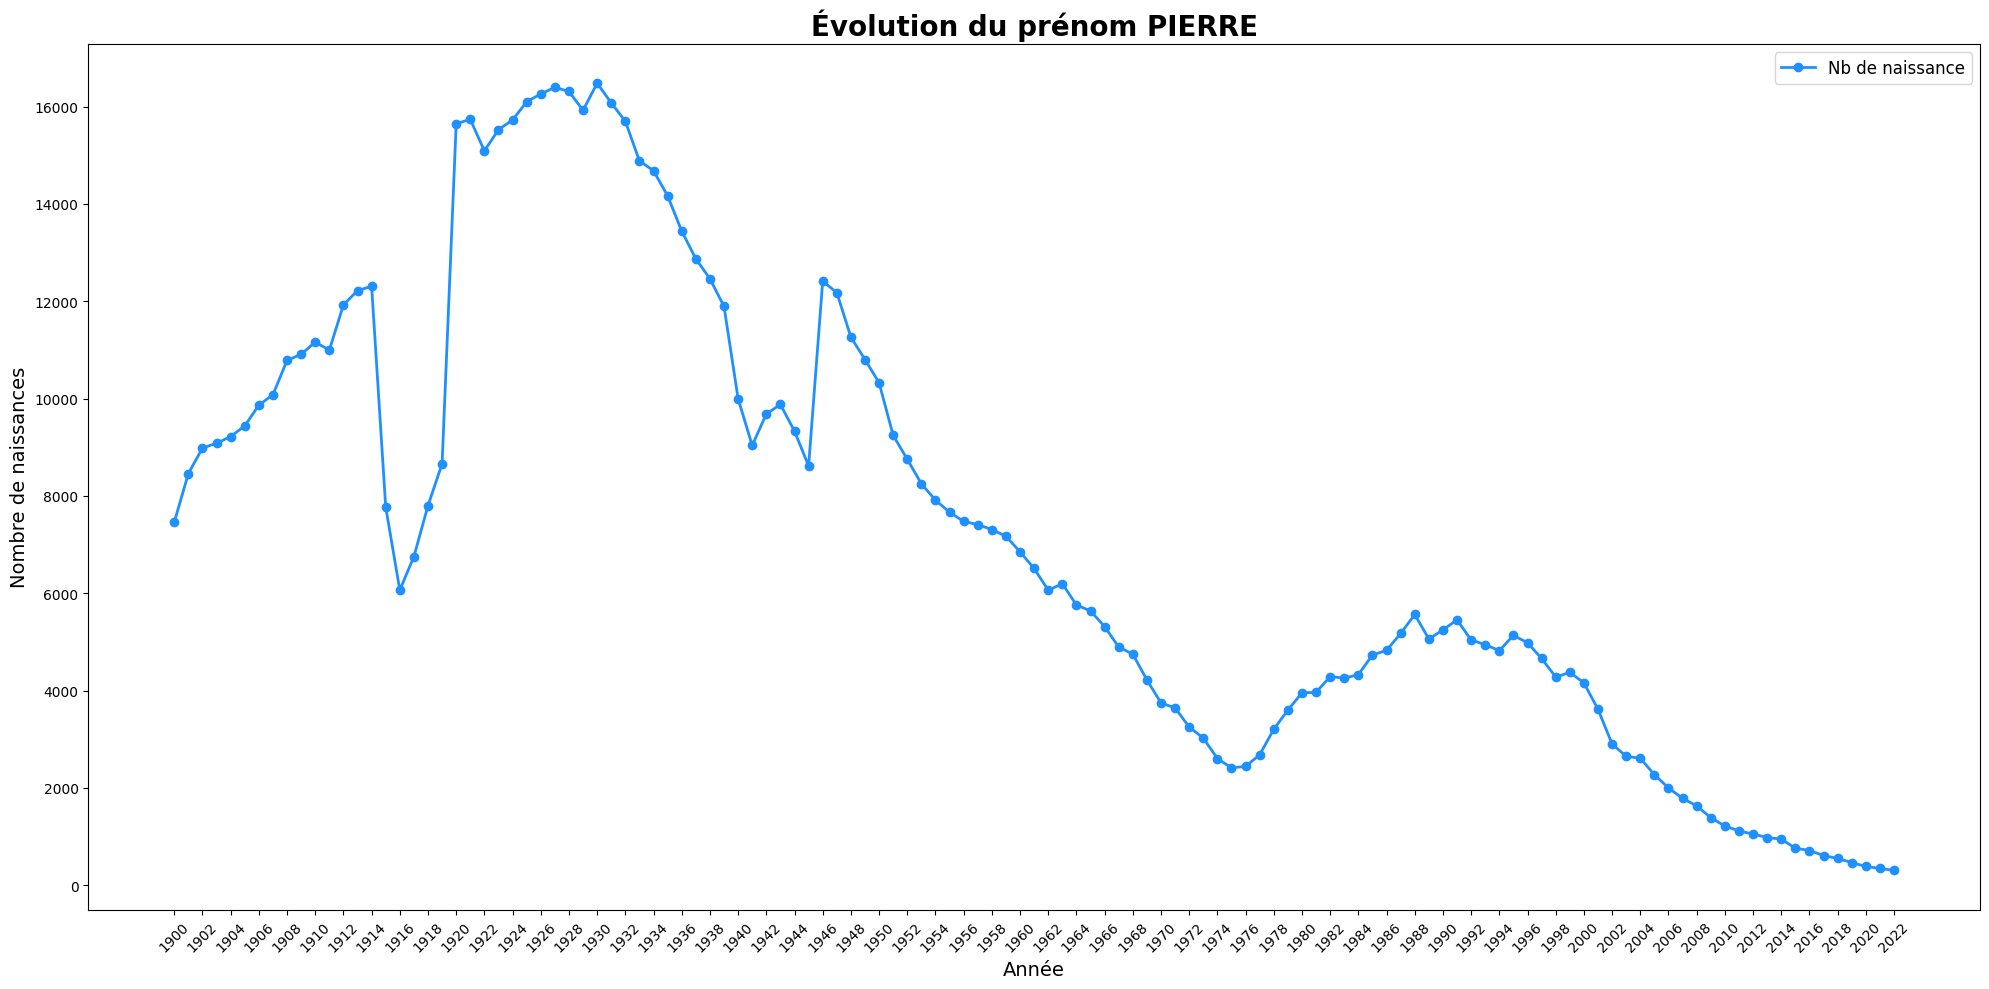

In [24]:
plot_ts_name_over_year(agg_year, prenom)

In [25]:
df_merge = merge_df_code_reg_dep(
    df_filtered,
    gpd.read_parquet("data/geojson/output/region_departement.parquet"),
)
df_merge

,year,dept,sex,name,count,code_dep,nom_reg,nom_dep,geometry_departement,code_reg,geometry_region
0,1900,971,1,PIERRE,23.0,971,Guadeloupe,Guadeloupe,"MULTIPOLYGON (((-4.51485 47.28135, -4.51887 47...",01,"MULTIPOLYGON (((-4.51485 47.28135, -4.51887 47..."
1,1900,972,1,PIERRE,58.0,972,Martinique,Martinique,"POLYGON ((-4.26197 46.34424, -4.26547 46.35394...",02,"POLYGON ((-4.26197 46.34424, -4.26547 46.35394..."
2,1900,972,2,PIERRE,7.0,972,Martinique,Martinique,"POLYGON ((-4.26197 46.34424, -4.26547 46.35394...",02,"POLYGON ((-4.26197 46.34424, -4.26547 46.35394..."
3,1900,973,NaN,NaN,0.0,973,Guyane,Guyane,"MULTIPOLYGON (((-4.13847 45.79417, -4.14167 45...",03,"MULTIPOLYGON (((-4.13847 45.79417, -4.14167 45..."
4,1900,974,1,PIERRE,94.0,974,La Réunion,La Réunion,"POLYGON ((-4.1983 44.81604, -4.19997 44.83709,...",04,"POLYGON ((-4.1983 44.81604, -4.19997 44.83709,..."
...,...,...,...,...,...,...,...,...,...,...,...
12528,2022,05,NaN,NaN,0.0,05,Provence-Alpes-Côte d'Azur,Hautes-Alpes,"POLYGON ((7.07587 44.68512, 7.07424 44.69209, ...",93,"MULTIPOLYGON (((7.71613 44.08003, 7.71313 44.0..."
12529,2022,04,NaN,NaN,0.0,04,Provence-Alpes-Côte d'Azur,Alpes-de-Haute-Provence,"POLYGON ((6.96709 44.62287, 6.9539 44.63783, 6...",93,"MULTIPOLYGON (((7.71613 44.08003, 7.71313 44.0..."
12530,2022,13,1,PIERRE,11.0,13,Provence-Alpes-Côte d'Azur,Bouches-du-Rhône,"POLYGON ((5.81325 43.68905, 5.78863 43.69672, ...",93,"MULTIPOLYGON (((7.71613 44.08003, 7.71313 44.0..."
12531,2022,20,1,PIERRE,4.0,20,Corse,Corse-du-Sud,"MULTIPOLYGON (((9.40712 41.76436, 9.40507 41.7...",94,"MULTIPOLYGON (((9.55982 42.28271, 9.55367 42.2..."


In [26]:
df_merge[(df_merge["year"] == "2010") & (df_merge["code_dep"] == "20")]

,year,dept,sex,name,count,code_dep,nom_reg,nom_dep,geometry_departement,code_reg,geometry_region
11319,2010,20,1,PIERRE,4.0,20,Corse,Corse-du-Sud,"MULTIPOLYGON (((9.40712 41.76436, 9.40507 41.7...",94,"MULTIPOLYGON (((9.55982 42.28271, 9.55367 42.2..."
11320,2010,20,1,PIERRE,4.0,20,Corse,Haute-Corse,"POLYGON ((9.55982 42.28271, 9.55367 42.29924, ...",94,"MULTIPOLYGON (((9.55982 42.28271, 9.55367 42.2..."


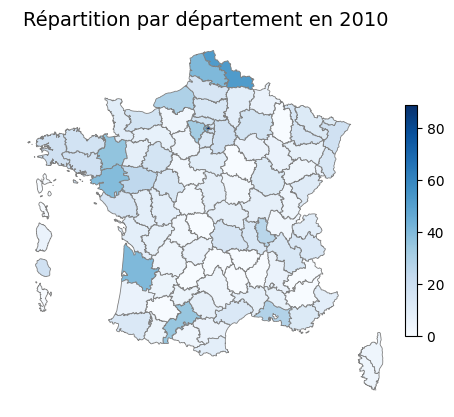

In [27]:
fig = plot_map_static_matplotlib(df_merge, "2010", "dep")

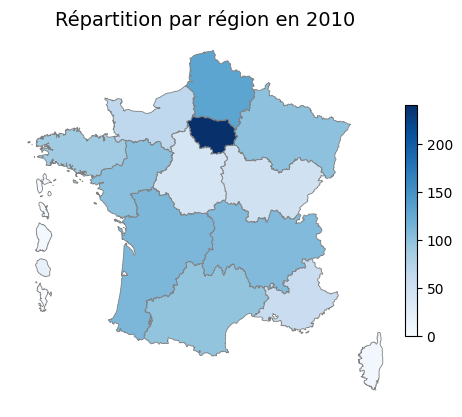

In [28]:
fig = plot_map_static_matplotlib(df_merge, "2010", "reg")